In [5]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

!curl -O https://raw.githubusercontent.com/tarikbahar/Turkish_names_and_surnames_dataset/master/Turkce_isimler_listesi.txt
tr_normalization_map=str.maketrans({
    'İ': 'i',
    'I': 'ı',
    'Â': 'a', 'â': 'a',
    'Î': 'i', 'î': 'i',
    'Û': 'u', 'û': 'u',
})

with open('Turkce_isimler_listesi.txt', 'r', encoding='utf-16') as f:
    lines=f.read().splitlines()

processed_words=[]

for line in lines:
    line=line.strip()
    if not line:
        continue
    raw_name=line.split(',')[0].strip()

    clean_name=raw_name.translate(tr_normalization_map).lower()

    if clean_name and clean_name.isalpha():
        processed_words.append(clean_name)

words=sorted(list(set(processed_words)))

print(f"Toplam temizlenen benzersiz isim sayısı: {len(words)}")
print("İlk 20 isim örneği:")
print(words[:20])

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 72050  100 72050    0     0   712k      0 --:--:-- --:--:-- --:--:--  717k
Toplam temizlenen benzersiz isim sayısı: 3110
İlk 20 isim örneği:
['aba', 'abadan', 'abak', 'abaka', 'abakan', 'abakay', 'abar', 'abasıyanık', 'abay', 'abaza', 'abaş', 'abaşkatun', 'abbas', 'abdal', 'abdan', 'abdi', 'abdullah', 'abdülhay', 'abdülhey', 'abdüssamed']


unsrançmokslbör.
e.
çerdış.
tmur.
baçulgüze.
tu.
çimengiyşbersa.
h.
at.
ürsayeç.
azmüyuturan.
ekadumı.
kemay.
ekar.
jdur.
aydum.
u.
ıy.
akç.
ikar.
3.910191297531128
3.2619094848632812
3.0253183841705322
2.8936779499053955
2.807246208190918
2.746441125869751
2.70176362991333
2.6680009365081787
2.641979932785034
2.621347188949585
2.6048245429992676
2.5911381244659424
2.579904794692993
2.570261001586914
2.562260150909424
2.555152177810669
2.5492615699768066
2.543829917907715
2.5393896102905273
2.535108804702759
2.5317015647888184
2.528228759765625
2.5255749225616455
2.5226781368255615
2.520585298538208
2.5181052684783936
2.5164384841918945
2.514268398284912
2.512932300567627
2.5109972953796387
2.509923219680786
2.508171558380127
2.5073087215423584
2.505704641342163
2.505013942718506
2.503530979156494
2.502983331680298
2.5016016960144043
2.501173734664917
2.4998793601989746
2.4995527267456055
2.4983327388763428
2.4980928897857666
2.496938705444336
2.4967732429504395
2.495676279067993
2.495

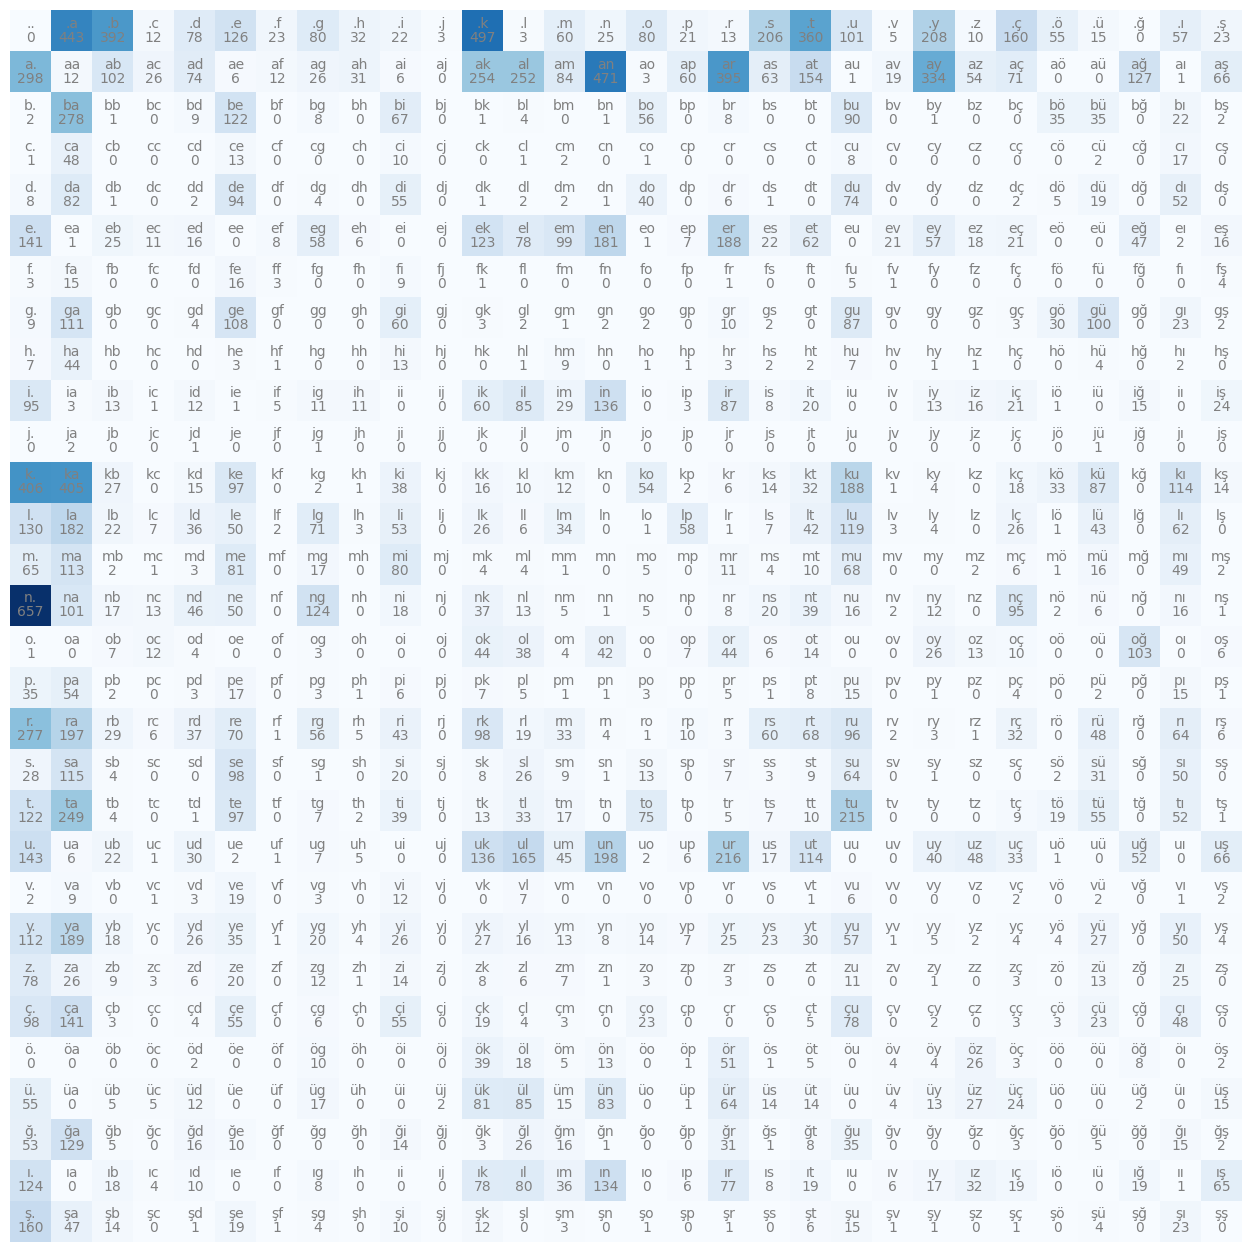

In [13]:
chars=sorted(list(set(''.join(words))))
stoi= {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos= {i:s for s,i in stoi.items()}
N=torch.zeros((len(stoi),len(stoi)), dtype=torch.int32)

for w in words:
   chs = ['.'] + list(w) + ['.']
   for ch1, ch2 in zip(chs, chs[1:]):
      ix1 = stoi[ch1]
      ix2 = stoi[ch2]
      N[ix1, ix2] += 1


plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(len(itos)):
    for j in range(len(itos)):
        chstr= itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color='gray')
plt.axis('off');

g=torch.Generator().manual_seed(2147483647)


P = (N + 1).float()
P /= P.sum(1, keepdim=True)

for i in range(20):
   out=[]
   ix=0
   while True:
     p=P[ix]
     ix=torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
     out.append(itos[ix])
     if ix==0:
       break
   print(''.join(out))


log_likelihood = 0.0
n=0
for w in words:
   chs = ['.'] + list(w) + ['.']
   for ch1, ch2 in zip(chs, chs[1:]):
      ix1 = stoi[ch1]
      ix2 = stoi[ch2]
      prob = P[ix1,ix2]
      logprob = torch.log(prob)
      log_likelihood += logprob
      n+=1
nll = -log_likelihood



xs, ys = [],[]
for w in words:
   chs = ['.'] + list(w) + ['.']
   for ch1, ch2 in zip(chs, chs[1:]):
      ix1 = stoi[ch1]
      ix2 = stoi[ch2]
      xs.append(ix1)
      ys.append(ix2)
xs=torch.tensor(xs)
ys=torch.tensor(ys)
num=xs.nelement()

W = torch.randn((len(stoi),len(stoi)), generator=g, requires_grad=True)

for k in range(50):
   xenc=F.one_hot(xs,num_classes=len(stoi)).float()
   logits=xenc@W
   counts=logits.exp()
   probs=counts/counts.sum(1,keepdims=True)
   loss=-probs[torch.arange(num),ys].log().mean() + 0.01*(W**2).mean()
   print(loss.item())
   W.grad=None
   loss.backward()
   W.data+= -100.0*W.grad

In [11]:
print(''.join(out))

ikar.


In [10]:
print(nll/n)

tensor(2.4546)
